In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.environ["LOGNAME"]  = "Yulia"
os.environ["USER"]     = "Yulia"
os.environ["USERNAME"] = "Yulia"

# Поиск корня проекта по маркеру PROJECT_CONTEXT.md
def find_project_root(marker="PROJECT_CONTEXT.md"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Не найден корень проекта (нет файла {marker})")

project_root = find_project_root()
print(f"Корень проекта: {project_root}")

data_path = project_root / "data" / "processed" / "training_set_v1.parquet"
print(f"Путь к данным : {data_path}")
print(f"Файл существует: {data_path.exists()}")

df = pd.read_parquet(data_path)
print(f"\nДатасет загружен: {df.shape}")
print(f"Период: {df['incident_hour'].min()} .. {df['incident_hour'].max()}")

Корень проекта: C:\metro-bus-ml
Путь к данным : C:\metro-bus-ml\data\processed\training_set_v1.parquet
Файл существует: True

Датасет загружен: (1394946, 14)
Период: 2024-10-01 00:00:00 .. 2024-12-31 22:00:00


In [2]:
# Feature engineering — 10 новых колонок
df["hour"]          = df["incident_hour"].dt.hour
df["day_of_week"]   = df["incident_hour"].dt.dayofweek
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)
df["month"]         = df["incident_hour"].dt.month
df["day_of_month"]  = df["incident_hour"].dt.day

df["time_of_day"] = pd.cut(
    df["hour"],
    bins=[-1, 6, 10, 16, 20, 24],
    labels=["night", "morning_rush", "midday", "evening_rush", "evening"],
)

df["status_main"] = df["status_label"].str.split().str[0].fillna("unknown")
df["is_express"]  = df["bus_route"].str.contains(r"\+$|X$", regex=True, na=False).astype(int)

# Принадлежность маршрута затронутой зоне (route_in_zone)
def route_in_affected_zone(row):
    if pd.isna(row["boroughs_affected_str"]) or pd.isna(row["route_borough"]):
        return 0
    return int(row["route_borough"] in row["boroughs_affected_str"])

df_feat = df.copy()
if "route_borough" not in df_feat.columns:
    borough_map = {"M": "Manhattan", "B": "Brooklyn", "Q": "Queens",
                   "BX": "Bronx", "S": "StatenIsland"}
    df_feat["route_prefix"] = df_feat["bus_route"].str.extract(r"^([A-Z]+)")
    df_feat["route_borough"] = df_feat["route_prefix"].map(borough_map).fillna("Unknown")

df_feat["route_in_zone"] = df_feat.apply(route_in_affected_zone, axis=1)

print(f"df_feat shape: {df_feat.shape}")

# Train/test split по времени
train_mask = (df_feat["incident_hour"] >= "2024-10-01") & (df_feat["incident_hour"] <= "2024-11-17")
test_mask  = (df_feat["incident_hour"] >= "2024-12-01") & (df_feat["incident_hour"] <= "2024-12-22")

train_df = df_feat[train_mask].copy()
test_df  = df_feat[test_mask].copy()

print(f"Train: {len(train_df):,} строк, {train_df['event_id'].nunique()} инцидентов")
print(f"Test : {len(test_df):,} строк, {test_df['event_id'].nunique()} инцидентов")
print(f"Mean target Train: {train_df['uplift_t1'].mean():+.2f}")
print(f"Mean target Test : {test_df['uplift_t1'].mean():+.2f}")

# Подготовка X / y
numeric_features = [
    "hour", "day_of_week", "is_weekend", "month", "day_of_month",
    "num_lines_affected", "n_boroughs_affected", "is_express", "route_in_zone",
    "baseline_t0", "baseline_t1", "actual_t0",
]
categorical_features = ["time_of_day", "status_main", "route_borough"]
target_col = "uplift_t1"

train_df = train_df.dropna(subset=[target_col])
test_df  = test_df.dropna(subset=[target_col])

X_train_num = train_df[numeric_features].copy()
X_test_num  = test_df[numeric_features].copy()

X_train_cat = pd.get_dummies(train_df[categorical_features], drop_first=False)
X_test_cat  = pd.get_dummies(test_df[categorical_features],  drop_first=False)

X_train = pd.concat([X_train_num.reset_index(drop=True),
                     X_train_cat.reset_index(drop=True)], axis=1)
X_test  = pd.concat([X_test_num.reset_index(drop=True),
                     X_test_cat.reset_index(drop=True)],  axis=1)

# Выравнивание колонок test по train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df[target_col].reset_index(drop=True)
y_test  = test_df[target_col].reset_index(drop=True)

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Признаков всего: {X_train.shape[1]}")

df_feat shape: (1394946, 25)
Train: 823,285 строк, 2807 инцидентов
Test : 386,310 строк, 1323 инцидентов
Mean target Train: +7.59
Mean target Test : +2.62

X_train: (823285, 32)
X_test : (386310, 32)
Признаков всего: 32


In [3]:
import os
import time
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.environ["LOGNAME"]  = "Yulia"
os.environ["USER"]     = "Yulia"
os.environ["USERNAME"] = "Yulia"

# Метрики
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = np.abs(y_true) > 1.0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return mae, rmse, mape, int(mask.sum())

# Распределение 32 признаков по 5 группам
all_features = list(X_train.columns)

feature_groups = {
    "temporal": [
        "hour", "day_of_week", "is_weekend", "month", "day_of_month",
    ] + [c for c in all_features if c.startswith("time_of_day_")],
    
    "incident": [
        "num_lines_affected", "n_boroughs_affected",
    ] + [c for c in all_features if c.startswith("status_main_")],
    
    "route": [
        "is_express", "route_in_zone",
    ] + [c for c in all_features if c.startswith("route_borough_")],
    
    "baseline_profile": [
        "baseline_t0", "baseline_t1",
    ],
    
    "incident_context": [
        "actual_t0",
    ],
}

# Проверка полноты разбиения
all_grouped = []
for group_features in feature_groups.values():
    all_grouped.extend(group_features)

missing = set(all_features) - set(all_grouped)
extra   = set(all_grouped) - set(all_features)

print("Распределение признаков по группам:")
print("=" * 60)
total = 0
for group_name, group_features in feature_groups.items():
    valid = [f for f in group_features if f in all_features]
    print(f"  {group_name:20s}: {len(valid):2d} признаков")
    for f in valid:
        print(f"      - {f}")
    total += len(valid)

print(f"\n  ИТОГО в группах: {total} признаков")
print(f"  В X_train      : {len(all_features)} признаков")

if missing:
    print(f"\n  ⚠ Не классифицированы: {missing}")
if extra:
    print(f"\n  ⚠ В группах есть отсутствующие в X_train: {extra}")

if not missing and not extra:
    print("\n  Разбиение полное.")

Распределение признаков по группам:
  temporal            : 10 признаков
      - hour
      - day_of_week
      - is_weekend
      - month
      - day_of_month
      - time_of_day_night
      - time_of_day_morning_rush
      - time_of_day_midday
      - time_of_day_evening_rush
      - time_of_day_evening
  incident            : 12 признаков
      - num_lines_affected
      - n_boroughs_affected
      - status_main_boarding-change
      - status_main_cancellations
      - status_main_delays
      - status_main_express-to-local
      - status_main_part-suspended
      - status_main_reroute
      - status_main_severe-delays
      - status_main_special-notice
      - status_main_stops-skipped
      - status_main_suspended
  route               :  7 признаков
      - is_express
      - route_in_zone
      - route_borough_Bronx
      - route_borough_Brooklyn
      - route_borough_Manhattan
      - route_borough_Queens
      - route_borough_Unknown
  baseline_profile    :  2 признаков
      

In [4]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mlflow.set_tracking_uri(f"file:{(project_root / 'mlruns').as_posix()}")
mlflow.set_experiment("metro_bus_uplift_v3_ablation")

# Лучшие параметры из Optuna (Day 5)
best_params = {
    "objective":        "reg:squarederror",
    "tree_method":      "hist",
    "random_state":     42,
    "n_jobs":           -1,
    "n_estimators":     150,
    "max_depth":        11,
    "learning_rate":    0.025394743526288403,
    "subsample":        0.7764516208812864,
    "colsample_bytree": 0.9728932430396474,
    "min_child_weight": 4,
    "reg_lambda":       0.85180641935179,
}

ablation_results = []

# Эксперимент 0: полная модель — точка отсчёта для ablation
print("=" * 70)
print("FULL MODEL (все 32 признака) — точка отсчёта")
print("=" * 70)

t_start = time.time()
model_full = xgb.XGBRegressor(**best_params)
model_full.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
train_time = time.time() - t_start
y_pred = model_full.predict(X_test)
mae_full, rmse_full, mape_full, _ = calc_metrics(y_test.values, y_pred)

print(f"MAE = {mae_full:.4f}, RMSE = {rmse_full:.4f}, время = {train_time:.1f} сек")

with mlflow.start_run(run_name="ablation_full_model"):
    mlflow.log_params({
        "ablation_type": "full",
        "removed_group": "none",
        "n_features":    X_train.shape[1],
    })
    mlflow.log_metrics({
        "mae":            mae_full,
        "rmse":           rmse_full,
        "mape":           mape_full if not np.isnan(mape_full) else -1.0,
        "train_time_sec": train_time,
        "mae_delta_pct":  0.0,
    })

ablation_results.append({
    "Группа удалена":     "—",
    "Признаков осталось": X_train.shape[1],
    "MAE":                round(mae_full, 4),
    "RMSE":               round(rmse_full, 4),
    "Δ_MAE":              0.0,
    "Δ_MAE_%":            0.0,
})

# Эксперименты 1-5: удаление каждой группы
for group_name, group_features in feature_groups.items():
    print(f"\n{'=' * 70}")
    print(f"ABLATION: удаляем группу '{group_name}' ({len(group_features)} признаков)")
    print("=" * 70)
    
    keep_cols = [c for c in X_train.columns if c not in group_features]
    X_train_sub = X_train[keep_cols]
    X_test_sub  = X_test[keep_cols]
    
    print(f"Признаков осталось: {len(keep_cols)} (было {X_train.shape[1]})")
    
    t_start = time.time()
    model_sub = xgb.XGBRegressor(**best_params)
    model_sub.fit(X_train_sub, y_train, eval_set=[(X_test_sub, y_test)], verbose=False)
    train_time = time.time() - t_start
    
    y_pred = model_sub.predict(X_test_sub)
    mae_sub, rmse_sub, mape_sub, _ = calc_metrics(y_test.values, y_pred)
    
    delta_mae     = mae_sub - mae_full
    delta_mae_pct = delta_mae / mae_full * 100
    
    print(f"MAE = {mae_sub:.4f} (Δ = {delta_mae:+.4f}, {delta_mae_pct:+.2f}%)")
    print(f"RMSE = {rmse_sub:.4f}")
    
    with mlflow.start_run(run_name=f"ablation_remove_{group_name}"):
        mlflow.log_params({
            "ablation_type":   "remove_group",
            "removed_group":   group_name,
            "removed_features": ",".join(group_features),
            "n_features":      len(keep_cols),
            "n_removed":       len(group_features),
        })
        mlflow.log_metrics({
            "mae":            mae_sub,
            "rmse":           rmse_sub,
            "mape":           mape_sub if not np.isnan(mape_sub) else -1.0,
            "train_time_sec": train_time,
            "mae_delta":      delta_mae,
            "mae_delta_pct":  delta_mae_pct,
        })
    
    ablation_results.append({
        "Группа удалена":     group_name,
        "Признаков осталось": len(keep_cols),
        "MAE":                round(mae_sub, 4),
        "RMSE":               round(rmse_sub, 4),
        "Δ_MAE":              round(delta_mae, 4),
        "Δ_MAE_%":            round(delta_mae_pct, 2),
    })

# Сводная таблица
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА ABLATION STUDY — раздел 3.3 ВКР")
print("=" * 80)
ablation_df = pd.DataFrame(ablation_results)
ablation_df_sorted = ablation_df.sort_values("Δ_MAE_%", ascending=False)
print(ablation_df_sorted.to_string(index=False))
print("=" * 80)

# Сохранение CSV для отчёта
output_path = project_root / "reports" / "ablation_study_v1.csv"
output_path.parent.mkdir(exist_ok=True)
ablation_df_sorted.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nТаблица сохранена: {output_path}")

2026/04/26 01:12:14 INFO mlflow.tracking.fluent: Experiment with name 'metro_bus_uplift_v3_ablation' does not exist. Creating a new experiment.


FULL MODEL (все 32 признака) — точка отсчёта
MAE = 10.7489, RMSE = 23.1835, время = 23.5 сек

ABLATION: удаляем группу 'temporal' (10 признаков)
Признаков осталось: 22 (было 32)
MAE = 10.5900 (Δ = -0.1589, -1.48%)
RMSE = 22.7150

ABLATION: удаляем группу 'incident' (12 признаков)
Признаков осталось: 20 (было 32)
MAE = 10.8267 (Δ = +0.0779, +0.72%)
RMSE = 23.4765

ABLATION: удаляем группу 'route' (7 признаков)
Признаков осталось: 25 (было 32)
MAE = 10.8170 (Δ = +0.0682, +0.63%)
RMSE = 23.4230

ABLATION: удаляем группу 'baseline_profile' (2 признаков)
Признаков осталось: 30 (было 32)
MAE = 12.5296 (Δ = +1.7807, +16.57%)
RMSE = 27.6241

ABLATION: удаляем группу 'incident_context' (1 признаков)
Признаков осталось: 31 (было 32)
MAE = 13.2141 (Δ = +2.4652, +22.93%)
RMSE = 30.6983

СВОДНАЯ ТАБЛИЦА ABLATION STUDY — раздел 3.3 ВКР
  Группа удалена  Признаков осталось     MAE    RMSE   Δ_MAE  Δ_MAE_%
incident_context                  31 13.2141 30.6983  2.4652    22.93
baseline_profile          

In [5]:
ablation_df_loaded = pd.read_csv(project_root / "reports" / "ablation_study_v1.csv", encoding="utf-8-sig")

print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА ABLATION STUDY (полный вывод)")
print("=" * 80)
print(ablation_df_loaded.to_string(index=False))
print("=" * 80)

СВОДНАЯ ТАБЛИЦА ABLATION STUDY (полный вывод)
  Группа удалена  Признаков осталось     MAE    RMSE   Δ_MAE  Δ_MAE_%
incident_context                  31 13.2141 30.6983  2.4652    22.93
baseline_profile                  30 12.5296 27.6241  1.7807    16.57
        incident                  20 10.8267 23.4765  0.0779     0.72
           route                  25 10.8170 23.4230  0.0682     0.63
               —                  32 10.7489 23.1835  0.0000     0.00
        temporal                  22 10.5900 22.7150 -0.1589    -1.48


ТОП-15 признаков по importance (XGBoost gain):
                 feature  importance
       time_of_day_night    0.620402
               actual_t0    0.076447
             baseline_t0    0.041720
                    hour    0.020905
time_of_day_evening_rush    0.019809
            day_of_month    0.018294
             day_of_week    0.018209
      time_of_day_midday    0.017770
             baseline_t1    0.017499
time_of_day_morning_rush    0.017156
                   month    0.011988
      num_lines_affected    0.011752
 route_borough_Manhattan    0.008717
              is_express    0.008715
              is_weekend    0.008613


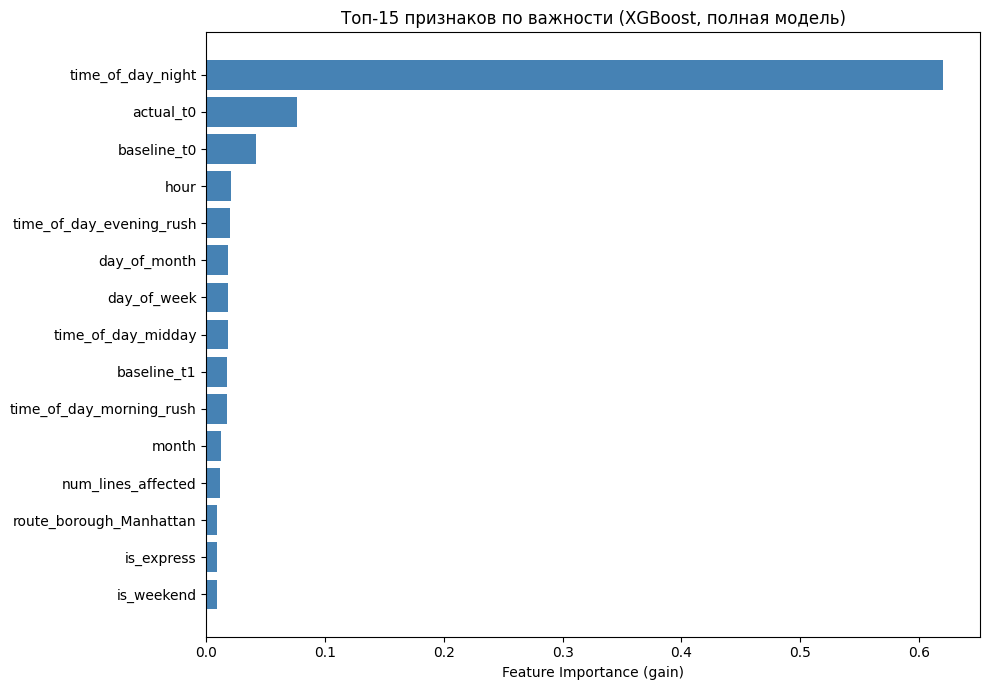


График сохранён: c:\metro-bus-ml\reports\feature_importance_top15.png


In [6]:
import matplotlib.pyplot as plt

# Feature importance из полной модели (32 признака, лучшие гиперпараметры)
importances = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": model_full.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("ТОП-15 признаков по importance (XGBoost gain):")
print(importances.head(15).to_string(index=False))

# График топ-15
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importances.head(15).iloc[::-1]
ax.barh(top15["feature"], top15["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Топ-15 признаков по важности (XGBoost, полная модель)")
plt.tight_layout()

fig_path = project_root / "reports" / "feature_importance_top15.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {fig_path}")